### Scraping

In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")

import warnings
warnings.filterwarnings('ignore')

In [2]:
url='https://steamdb.info/charts/'
driver.get(url)

In [3]:
select_element = driver.find_element(By.CSS_SELECTOR, 'select[aria-controls="table-apps"]')
Select(select_element).select_by_visible_text('All')

In [4]:
hrefs={e.text:e.get_attribute('href') for e in driver.find_elements(By.CSS_SELECTOR, 'table tr a[class="b"]')}

In [ ]:
ids={k.strip():v.split('/charts')[0].split('app/')[-1] for k, v in hrefs.items()}

In [9]:
data={}
bad_urls=[]

for i, (game, id_) in enumerate(ids.items(), start=1):
    try:
        url=f'https://steamcharts.com/app/{id_}#All'
        html=requests.get(url, headers).content
        table=pd.read_html(html)[0]
    
        player_dict={}
        for index, row in table.iterrows():
            month=row['Month']
            players=row['Avg. Players']
            if not month.startswith('Last'):
                player_dict.update({month:players})
        data.update({game:player_dict})
        
        print(f'{i}/{len(ids)}',end='\r')
        
    except:
        bad_urls.append(url)
        continue


1743/1750

### Cleaning&Analyzing

In [2]:
#pickle.dump(data, open('steamcharts.pickle','wb'))
data=pickle.load( open('steamcharts.pickle','rb'))

In [3]:
df = pd.DataFrame.from_dict(data, orient='index').rename_axis('Game').reset_index().melt(id_vars='Game', var_name='Month', value_name='Count')

In [4]:
df['Month']=pd.to_datetime(df['Month']).dt.to_period('Y')
df=df.rename(columns={'Month':'Year'})

In [5]:
df['Count']=df['Count'].astype(float)

In [6]:
df=df.sort_values(['Game','Year'])

In [7]:
df=df.dropna(subset='Count')

In [8]:
grouped=df.groupby(['Game','Year'])['Count'].mean().reset_index()

In [9]:
grouped=grouped.groupby('Game').filter(lambda x:x['Count'].mean()>=10000 and x['Year'].count()>=5)
#grouped[grouped['Year']!="2026"]
grouped=grouped.reset_index()

In [10]:
grouped

,index,Game,Year,Count
0,30,7 Days to Die,2013,1377.67
1,31,7 Days to Die,2014,3082.27
2,32,7 Days to Die,2015,4811.58
3,33,7 Days to Die,2016,7493.43
4,34,7 Days to Die,2017,10939.98
...,...,...,...,...
868,11024,tModLoader,2022,18760.77
869,11025,tModLoader,2023,22523.77
870,11026,tModLoader,2024,25570.71
871,11027,tModLoader,2025,26985.54


In [11]:
games_increasing = (
    grouped.sort_values(['Game','Year'])
      .groupby('Game')['Count']
      .apply(lambda x: (x.diff().dropna() >= 0).all())
)

games_increasing = games_increasing[games_increasing].index
games_increasing

#games increasing YoY

Index(['OBS Studio', 'VRChat', 'Wallpaper Engine', 'tModLoader'], dtype='object', name='Game')

In [12]:
growth = (
    grouped.sort_values(['Game','Year'])
      .groupby('Game')['Count']
      .pct_change()
)

avg_growth = growth.groupby(grouped['Game']).median()
avg_growth.sort_values(ascending=False)

#median growth rate of each game

Game
Crosshair X           2.16
OBS Studio            0.59
Geometry Dash         0.56
Spacewar              0.41
VRChat                0.35
                      ... 
Fall Guys            -0.48
Lost Ark             -0.54
FIFA 22              -0.55
EA SPORTS™ FIFA 23   -0.57
Crab Game            -0.66
Name: Count, Length: 89, dtype: float64

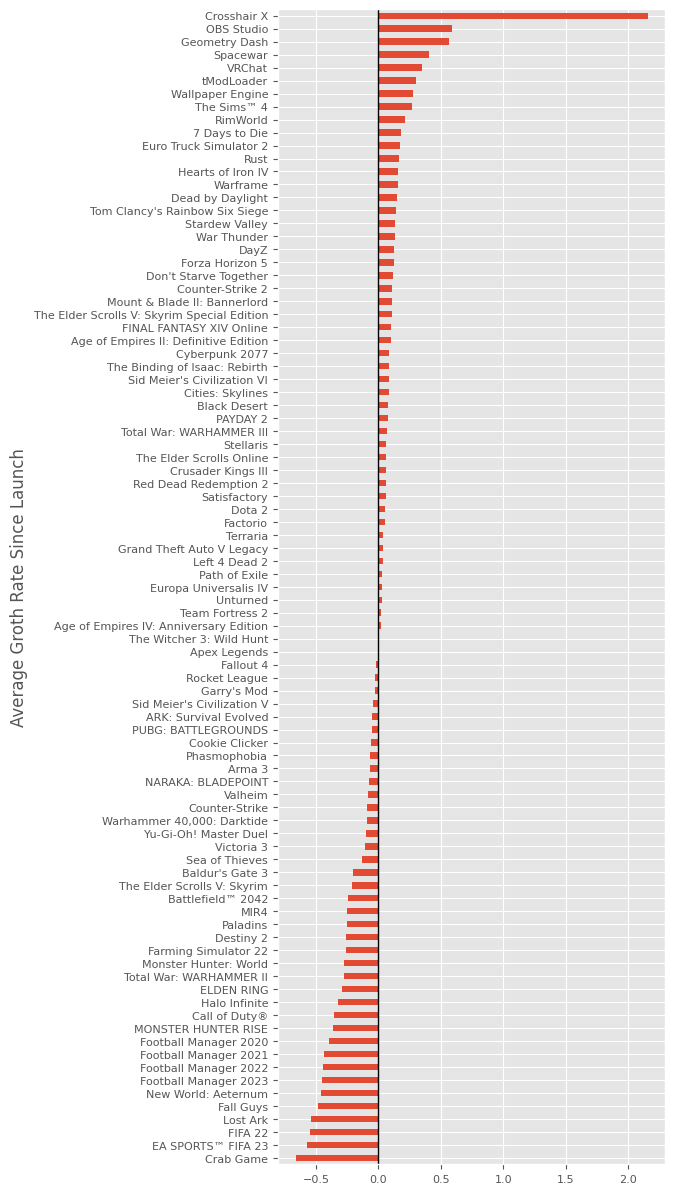

In [26]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

avg_growth.sort_values(ascending=True).plot.barh(fontsize=8,figsize=(5,15))
plt.axvline(0,lw=1, color='black')
plt.ylabel('Average Groth Rate Since Launch')
plt.show()